In [193]:
from pathlib import Path

HOME = Path.cwd()
print(HOME)

c:\Users\patrickcruz\Documents\Professional\Github\contagem-de-pessoas\count-github-yolo-01\notebooks


In [194]:
%pip install -q "ultralytics>=8.4.0" supervision roboflow

# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.4.50  Python-3.13.9 torch-2.12.0+cpu CPU (AMD Ryzen Threadripper PRO 5965WX 24-Cores)
Setup complete  (48 CPUs, 127.8 GB RAM, 1485.3/1641.6 GB disk)


In [195]:
!powershell -Command "Invoke-WebRequest -Uri 'https://media.roboflow.com/notebooks/examples/dog-2.jpeg' -OutFile 'dog-2.jpeg'"
!powershell -Command "Invoke-WebRequest -Uri 'https://media.roboflow.com/notebooks/examples/dog-3.jpeg' -OutFile 'dog-3.jpeg'"

In [196]:
file = "dog-2.jpeg"
file_source = HOME / file

In [197]:
from ultralytics import YOLO

model = YOLO("yolo26m.pt")
if model is not None:
    print("Model loaded successfully.")

Model loaded successfully.


In [198]:
results = model.predict(
    source=file_source,
    save=True,
    verbose=False,
    project=HOME / "runs" / "detect",
    name="predict",
    exist_ok=True,
)
prediction = results[0]
prediction_dir = Path(prediction.save_dir)
print(f"Predictions saved to {prediction_dir}")

Results saved to C:\Users\patrickcruz\Documents\Professional\Github\contagem-de-pessoas\count-github-yolo-01\notebooks\runs\detect\predict
Predictions saved to C:\Users\patrickcruz\Documents\Professional\Github\contagem-de-pessoas\count-github-yolo-01\notebooks\runs\detect\predict


In [199]:
prediction_dir = Path(prediction_dir)

if not prediction_dir.exists():
    print(f"Prediction directory not found: {prediction_dir}")
else:
    print(f"Listing {prediction_dir}")
    for item in sorted(prediction_dir.iterdir()):
        print(item.name)

Listing C:\Users\patrickcruz\Documents\Professional\Github\contagem-de-pessoas\count-github-yolo-01\notebooks\runs\detect\predict
dog-2.jpg
dog-3.jpg


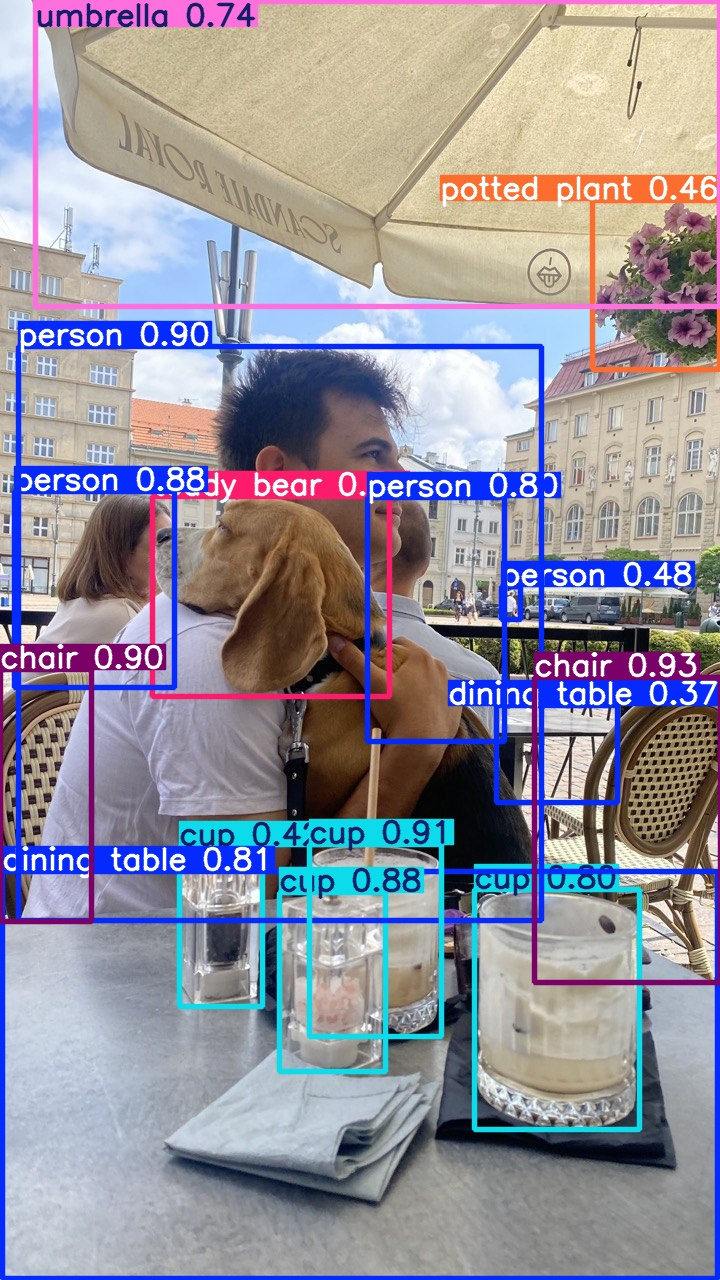

In [200]:
from IPython.display import Image as IPyImage

filename = str(prediction_dir / f"{Path(file).stem}.jpg")
IPyImage(filename=filename, width=600)